# High-Value Orders Analysis

## Objective

Identify orders with sales above the overall average and analyze their characteristics, including:
- Product Category
- Customer Segment
- Region
- Order Priority

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../datas/cleaned_ecommerce.csv")

In [2]:
average_sales = df["Sales"].mean()

print(f"Overall Average Sales: ${average_sales:,.2f}")

Overall Average Sales: $156.43


In [3]:
high_value_orders = df[df["Sales"] > average_sales]

high_value_orders.head()

,Order ID,Order Date,Ship Date,Aging,Ship Mode,Product Category,Product,Sales,Quantity,Discount,...,Shipping Cost,Order Priority,Customer ID,Customer Name,Segment,City,State,Country,Region,Months
1,AU-2015-2,2015-06-30,2015-07-02,2.0,First Class,Auto & Accessories,Car Speakers,211.0,3.0,0.03,...,11.2,Medium,IZ-002,Alvarado Kriz,Home Office,Berlin,Berlin,Germany,Central,Jun
4,AU-2015-5,2015-07-09,2015-07-18,9.0,First Class,Auto & Accessories,Tyre,250.0,1.0,0.04,...,16.0,Critical,ON-005,Rowe Jackson,Corporate,Townsville,Queensland,Australia,Oceania,Jul
8,AU-2015-9,2015-02-09,2015-02-16,7.0,First Class,Auto & Accessories,Car Pillow & Neck Rest,231.0,5.0,0.03,...,11.6,Critical,EN-009,Wall Olsen,Consumer,Juárez,Chihuahua,Mexico,North,Feb
10,AU-2015-11,2015-11-16,2015-11-26,10.0,First Class,Auto & Accessories,Car Speakers,211.0,4.0,0.01,...,12.3,Critical,ED-0011,Johns Reed,Corporate,Taipei,Taipei City,Taiwan,North Asia,Nov
13,AU-2015-14,2015-07-22,2015-07-27,5.0,First Class,Auto & Accessories,Tyre,250.0,3.0,0.04,...,14.0,High,AN-0014,Johnson Abelman,Corporate,Kamina,Katanga,Democratic Republic of the Congo,Africa,Jul


In [4]:
print("=" * 50)
print(f"Total High-Value Orders : {len(high_value_orders)}")
print(f"Average Sales           : ${high_value_orders['Sales'].mean():,.2f}")
print(f"Maximum Sales           : ${high_value_orders['Sales'].max():,.2f}")
print("=" * 50)

Total High-Value Orders : 26301
Average Sales           : $215.00
Maximum Sales           : $250.00


In [5]:
category_analysis = (
    high_value_orders.groupby("Product Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Orders=("Order ID", "count")
    )
    .sort_values(by="Total_Sales", ascending=False)
)

category_analysis

,Total_Sales,Orders
Product Category,,
Fashion,4152867.0,19563
Home & Furniture,673124.0,3083
Auto & Accessories,588824.0,2547
Electronic,239919.0,1108


In [6]:
segment_analysis = (
    high_value_orders.groupby("Segment")
    .agg(
        Total_Sales=("Sales", "sum"),
        Orders=("Order ID", "count")
    )
    .sort_values(by="Total_Sales", ascending=False)
)

segment_analysis

,Total_Sales,Orders
Segment,,
Consumer,2901313.0,13515
Corporate,1712907.0,7964
Home Office,1040514.0,4822


In [7]:
region_analysis = (
    high_value_orders.groupby("Region")
    .agg(
        Total_Sales=("Sales", "sum"),
        Orders=("Order ID", "count")
    )
    .sort_values(by="Total_Sales", ascending=False)
)

region_analysis

,Total_Sales,Orders
Region,,
Central,1217600.0,5680
South,725847.0,3386
EMEA,558119.0,2591
North,532871.0,2477
Africa,502683.0,2340
Oceania,383960.0,1780
Southeast Asia,362748.0,1683
West,348829.0,1620
East,312123.0,1443


In [8]:
priority_analysis = (
    high_value_orders.groupby("Order Priority")
    .agg(
        Total_Sales=("Sales", "sum"),
        Orders=("Order ID", "count")
    )
    .sort_values(by="Total_Sales", ascending=False)
)

priority_analysis

,Total_Sales,Orders
Order Priority,,
Medium,3473081.0,16247
High,1560566.0,7198
Low,328359.0,1544
Critical,292247.0,1310


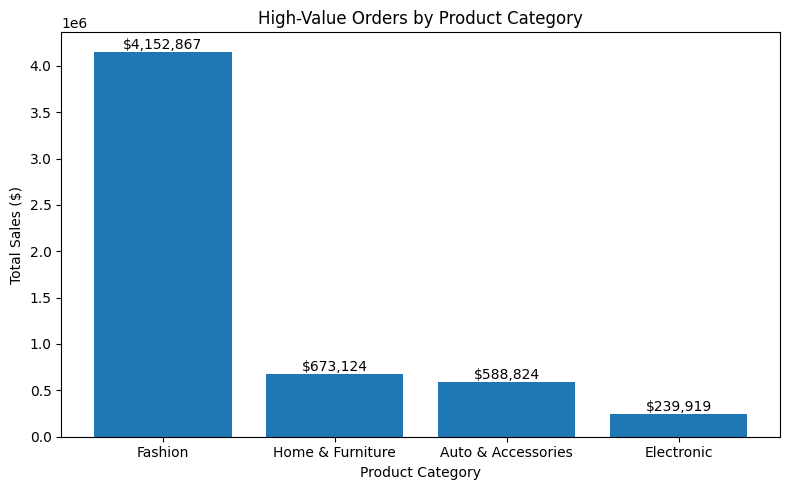

In [9]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    category_analysis.index,
    category_analysis["Total_Sales"]
)

plt.title("High-Value Orders by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales ($)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("../charts/high_value_category.png", dpi=300)

plt.show()

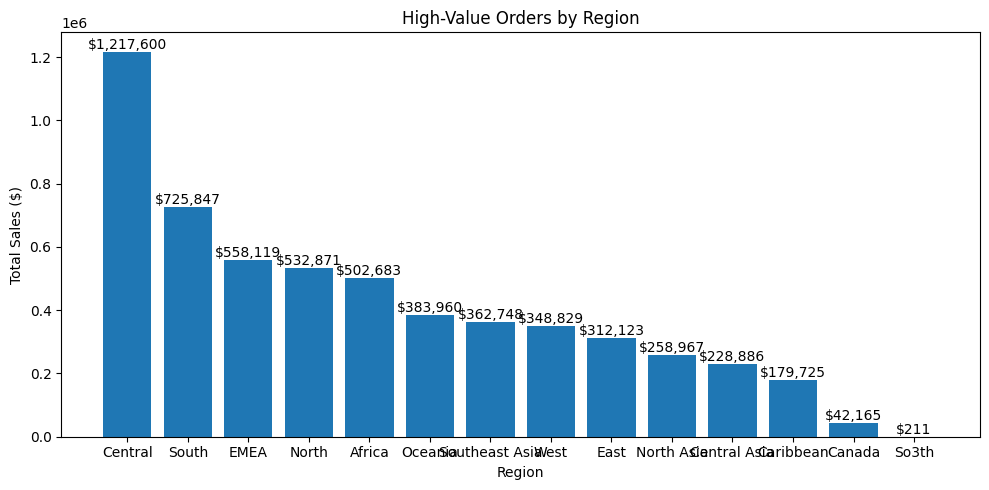

In [11]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    region_analysis.index,
    region_analysis["Total_Sales"]
)

plt.title("High-Value Orders by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("../charts/high_value_region.png", dpi=300)

plt.show()

## Business Insights

- Identified all orders with sales above the overall average.
- Analyzed high-value orders by product category, customer segment, region, and order priority.
- Identified the characteristics of the company's highest-value transactions.

### Recommendations

- Prioritize high-performing product categories.
- Target customer segments that frequently place high-value orders.
- Focus marketing efforts on regions with a high concentration of valuable orders.
- Offer premium services or loyalty programs to high-value customers.